# Assignment 5

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

Additional notes:

* Please note that in this assignment, students are expected to work independently. As a result, no two solutions should look identical in terms of coding;
* You may import any libraries you need to complete the assignment. However, you must implement the model using TensorFlow (do not use PyTorch);
* Follow the same steps/idea as in Assignment 4; the difference here is that you extend a logistic model to more than two classes;
* <span style="color:chocolate"> Focus on the execution of the task rather than model performance </span> (this is how the TA will grade your work);
* Even though the prediction performance for your chosen outcome is low, it doesn't necessarily mean there is something wrong with your implementation. It could also be that the data is not supportive enough for your prediction task... again, focus on the learning opportunity and not the numbers you get;
* Your instructional team has extensive experience developing and running ML models. Often, we encounter situations where a model doesn't perform well on a predictive task. This can happen due to the nature of the data or the need for significant tweaking of variables to achieve good results;
* Do not spend significantly more time on this task than you did on Assignment 4, unless you wish to experiment and learn more.
---

``Objective``
* Perform multiclass classification using logistic regression. <span style="color:chocolate"> You will choose the outcome of interest. </span>

``Motivation``
* Chocolate is one of the most popular candies in the world. Each year, residents of the United States collectively eat more than 2.8 billions pounds (Source: Kaggle). However, not all chocolate bars are created equal! In this assignment, you will have the opportunity to delve into the world of chocolate by choosing your own machine learning task. 


``Data``

* The [Chocolate Bar dataset](https://www.kaggle.com/datasets/rtatman/chocolate-bar-ratings) contains expert ratings of 1,795 individual chocolate bars, along with information on their regional origin, percentage of cocoa, the variety of chocolate bean used and where the beans were grown (Source: Kaggle).

### Import libraries

In [1]:
%reset -f
from __future__ import print_function

import math
import numpy as np
import numpy.linalg as nla
import pandas as pd
import re
import six
from os.path import join
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from keras_tuner import HyperParameters
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support

# feel free to import other libraries as needed

import warnings
warnings.filterwarnings('ignore')

2025-06-15 17:38:22.458164: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-15 17:38:22.462884: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-15 17:38:22.544047: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-15 17:38:22.544131: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-15 17:38:22.553458: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

### Define functions

In [2]:
def read_data():
    ''''''
    # Read data
    df = pd.read_csv(
        "https://download.mlcc.google.com/mledu-datasets/flavors_of_cacao.csv",
        sep=",",
        encoding='latin-1'
    )
    
    return df

In [3]:
def clean_data(df):
    ''''''
    # Set the output display to have one digit for decimal places and limit it to
    # printing 15 rows.
    pd.options.display.float_format = '{:.2f}'.format
    pd.options.display.max_rows = 15
    
    # Rename the columns.
    df.columns = [
        'maker', 'specific_origin', 'reference_number',
        'review_date', 'cocoa_percent', 'maker_location',
        'rating', 'bean_type', 'broad_origin'
    ]

    # df.dtypes

    # Replace empty/null values with "Blend"
    df['bean_type'] = df['bean_type'].fillna('Blend')

    # Cast bean_type to string to remove leading 'u'
    df['bean_type'] = df['bean_type'].astype(str)
    df['cocoa_percent'] = df['cocoa_percent'].str.strip('%')
    df['cocoa_percent'] = pd.to_numeric(df['cocoa_percent'])

    # Correct spelling mistakes, and replace city with country name
    df['maker_location'] = df['maker_location']\
    .str.replace('Amsterdam', 'Holland')\
    .str.replace('U.K.', 'England')\
    .str.replace('Niacragua', 'Nicaragua')\
    .str.replace('Domincan Republic', 'Dominican Republic')

    # Adding this so that Holland and Netherlands map to the same country.
    df['maker_location'] = df['maker_location']\
    .str.replace('Holland', 'Netherlands')

    def cleanup_spelling_abbrev(text):
        replacements = [
            ['-', ', '], ['/ ', ', '], ['/', ', '], ['\(', ', '], [' and', ', '], [' &', ', '], ['\)', ''],
            ['Dom Rep|DR|Domin Rep|Dominican Rep,|Domincan Republic', 'Dominican Republic'],
            ['Mad,|Mad$', 'Madagascar, '],
            ['PNG', 'Papua New Guinea, '],
            ['Guat,|Guat$', 'Guatemala, '],
            ['Ven,|Ven$|Venez,|Venez$', 'Venezuela, '],
            ['Ecu,|Ecu$|Ecuad,|Ecuad$', 'Ecuador, '],
            ['Nic,|Nic$', 'Nicaragua, '],
            ['Cost Rica', 'Costa Rica'],
            ['Mex,|Mex$', 'Mexico, '],
            ['Jam,|Jam$', 'Jamaica, '],
            ['Haw,|Haw$', 'Hawaii, '],
            ['Gre,|Gre$', 'Grenada, '],
            ['Tri,|Tri$', 'Trinidad, '],
            ['C Am', 'Central America'],
            ['S America', 'South America'],
            [', $', ''], [',  ', ', '], [', ,', ', '], ['\xa0', ' '],[',\s+', ','],
            [' Bali', ',Bali']
        ]
        for i, j in replacements:
            text = re.sub(i, j, text)
        return text

    df['specific_origin'] = df['specific_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Cast specific_origin to string
    df['specific_origin'] = df['specific_origin'].astype(str)

    # Replace null-valued fields with the same value as for specific_origin
    df['broad_origin'] = df['broad_origin'].fillna(df['specific_origin'])

    # Clean up spelling mistakes and deal with abbreviations
    df['broad_origin'] = df['broad_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Change 'Trinitario, Criollo' to "Criollo, Trinitario"
    # Check with df['bean_type'].unique()
    df.loc[df['bean_type'].isin(['Trinitario, Criollo']),'bean_type'] = "Criollo, Trinitario"
    # Confirm with df[df['bean_type'].isin(['Trinitario, Criollo'])]

    # Fix chocolate maker names
    df.loc[df['maker']=='Shattel','maker'] = 'Shattell'
    df['maker'] = df['maker'].str.replace(u'Na\xef\xbf\xbdve','Naive')

    return df

---
### Step 1: Data ingestion

First, we'll initiate the process of discovering the chocolate world by loading the data. Then, to assist with this assignment, we'll start by tidying up the data a little bit. This involves renaming columns and conducting some string preprocessing tasks, which will be handled by the <span style="color:chocolate">clean_data()</span> function mentioned earlier.

In [4]:
df = clean_data(read_data())
print('Shape of data', df.shape)
df.head()

Shape of data (1795, 9)


,maker,specific_origin,reference_number,review_date,cocoa_percent,maker_location,rating,bean_type,broad_origin
0,A. Morin,Agua Grande,1876,2016,63.00,France,3.75,Blend,Sao Tome
1,A. Morin,Kpime,1676,2015,70.00,France,2.75,Blend,Togo
2,A. Morin,Atsane,1676,2015,70.00,France,3.00,Blend,Togo
3,A. Morin,Akata,1680,2015,70.00,France,3.50,Blend,Togo
4,A. Morin,Quilla,1704,2015,70.00,France,3.50,Blend,Peru


### <span style="color:chocolate">Exercise 1:</span> Getting to know the data (5 points)

Answer the following questions:
    
1. How many columns does the dataset contain?
2. How many rows are there in the dataset?
3. What are the column names?
4. List the number of unique values for each column in the data;
5. What are the unique cocoa_percent values?

In [5]:
# YOUR CODE HERE

print(df.shape)
print(df.columns)

'''The dataset contains 9 columns'''
'''The dataset contains 1795 rows'''
'''The column names are maker, specific_origin, reference_number, review_date, cocoa_percent, maker_location, rating, bean_type, broad_origin'''

print(df.nunique())
print(df['cocoa_percent'].nunique())

(1795, 9)
Index(['maker', 'specific_origin', 'reference_number', 'review_date',
       'cocoa_percent', 'maker_location', 'rating', 'bean_type',
       'broad_origin'],
      dtype='object')
maker                414
specific_origin     1038
reference_number     440
review_date           12
cocoa_percent         45
maker_location        58
rating                13
bean_type             39
broad_origin         160
dtype: int64
45


### <span style="color:chocolate">Exercise 2:</span> Choosing the prediction task (5 points)

Now that you’ve explored the data, choose a multiclass outcome (anything except "ratings") that you’re interested in predicting. Note: The outcome should have <span style="color:chocolate">at least 3 classes</span>!

If your chosen outcome variable requires preprocessing, go ahead and handle that below. For instance, you might choose to predict "cocoa_percent". Discretizing it into "0=low," "1=medium," and "2=high" makes it easier to work with/interpret the results.

Your answer here: 

In [6]:
# YOUR CODE HERE

bins = [0,65,75,100]
labels = [1,2,3]

df['cocoa_category'] = pd.cut(df['cocoa_percent'], bins=bins, labels=labels, include_lowest=True)
df[['cocoa_category','cocoa_percent']].head()

Y = df['cocoa_category']

---
### Step 2: Data preprocessing

### <span style="color:chocolate">Exercise 3:</span> Prepare data for modeling (20 points)

Following the format of previous assignments, adhere to the following steps as a minimum:

1. Shuffle the dataset;
2. Create training, validation, and test datasets using a 60/20/20 split;
3. Identify the features of interest;
4. Perform necessary cleaning and standarization on the features.

In [7]:
# YOUR CODE HERE

np.random.seed(0)

#shuffling

df_shuffled = df.sample(frac=1, random_state=1234).reset_index(drop=True)

features = ['broad_origin','bean_type','specific_origin']

X = pd.get_dummies(df_shuffled[features], drop_first=True, dtype=float)

Y = df_shuffled['cocoa_category']


#splitting

X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.4, random_state=1234)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=1234)

print(X_train.shape)
print(Y_train.shape)
print(X_val.shape)
print(Y_val.shape)
print(X_temp.shape)
print(Y_temp.shape)

(1077, 1234)
(1077,)
(359, 1234)
(359,)
(718, 1234)
(718,)


---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 4:</span> Plots (20 points)

In line with the structure of previous assignments, execute the following steps:

1. Generate a minimum of 4 plots to investigate features and outcome within the training dataset;
2. Ensure that each plot includes clear axis labels and titles;
3. Provide commentary on the insights learned from your visualizations.

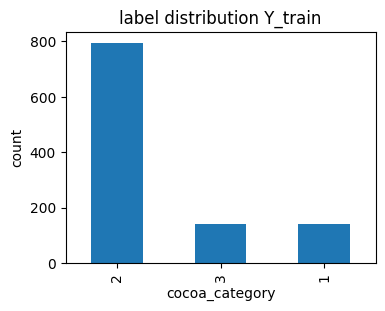

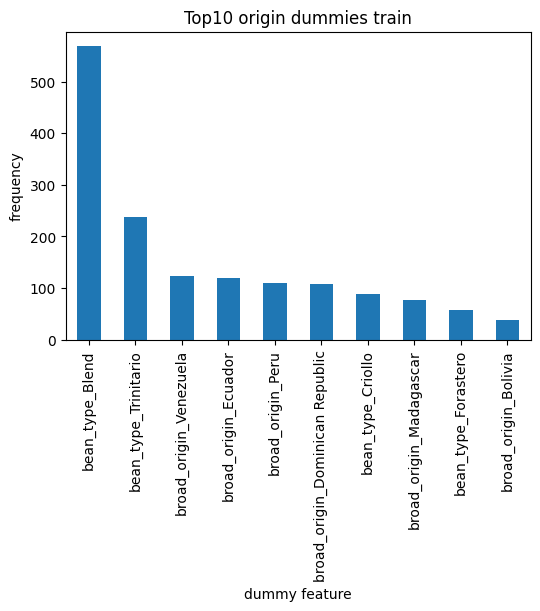

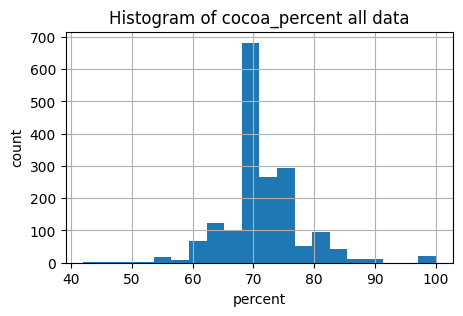

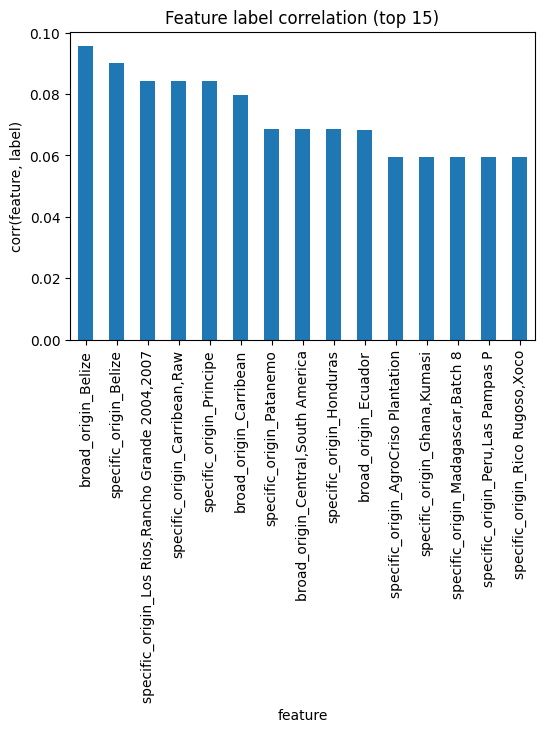

' Number 2 which refers to medium, is the most common cocoa category, the bean tipe blend is far more common than other types of bean, it even looks like an outlier. The percentage of cocoa has normal distribution. This highest correlation of a bean type with the cocoa category is just 0.10'

In [8]:
# YOUR CODE HERE

# classes distribution
plt.figure(figsize=(4,3))
Y_train.value_counts().plot(kind='bar')
plt.title('label distribution Y_train')
plt.xlabel('cocoa_category')
plt.ylabel('count')
plt.show()

# dummies top 10
plt.figure(figsize=(6,4))
X_train.sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top10 origin dummies train')
plt.xlabel('dummy feature')
plt.ylabel('frequency')
plt.show()

# histogram of original
plt.figure(figsize=(5,3))
df['cocoa_percent'].hist(bins=20)
plt.title('Histogram of cocoa_percent all data')
plt.xlabel('percent')
plt.ylabel('count')
plt.show()

# correlation features
corr_df = pd.concat([X_train, Y_train], axis=1)

feat_corr = corr_df.corr()['cocoa_category'].drop('cocoa_category').sort_values(ascending=False)
plt.figure(figsize=(6,4))
feat_corr.head(15).plot(kind='bar')
plt.title('Feature label correlation (top 15)')
plt.xlabel('feature')
plt.ylabel('corr(feature, label)')
plt.show()


#insights
''' Number 2 which refers to medium, is the most common cocoa category, the bean tipe blend is far more common than other types of bean, it even looks like an outlier. The percentage of cocoa has normal distribution. This highest correlation of a bean type with the cocoa category is just 0.10'''

---
### Step 4: Modeling

### <span style="color:chocolate">Exercise 5:</span> Baseline model (10 points)

When dealing with classification problems, a simple baseline is to select the *majority* class (the most common label in the training set) and use it as the prediction for all inputs.

1. Implement this baseline and report the accuracy metric on the train data;

2. Implement a function that computes the Log Loss (cross-entropy loss) metric and use it to evaluate this baseline on both the train and validation data. Note: reflect on what you know about the original distribution of classes in your training data (Hint: see Assignment 4 - Exercise 8 and ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example).

In [9]:
# YOUR CODE HERE

majority_class = Y_train.value_counts().idxmax()
print(majority_class)

## cross entropy loss

n_classes = 4
one_hot = np.zeros(n_classes)
one_hot[2] = 1.0
preds_train = np.tile(one_hot, (len(Y_train), 1))
preds_val   = np.tile(one_hot, (len(Y_val),   1))

acc_train = (Y_train == 2).mean()
acc_val   = (Y_val   == 2).mean()

def ce_loss(preds, Y):
  """
    preds are (m,n) m = number of examples, n = number of classes
    Y is (m,) -- array of sparse labels 
    preds[0] = [.1, .1, .8] Y[0] = 2 Y_dense[0] = [0, 0, 1]
  """
  # Get the number of examples
  m = Y.shape[0]

  # the rows of the predictions and corresponding labels.
  Y_dense = tf.keras.utils.to_categorical(Y)
  # [.1, .1, .8] [0, 0, 1] -> [0, 0, -1*log(.8)] -> -1*log(.8)
  cross_entropy_values = - np.sum(Y_dense * np.log(preds), axis=1)

  loss = -np.log(preds[np.arange(m), Y]).mean()
  return loss

print(acc_train)
print(acc_val)
print(ce_loss(preds_train, Y_train.values))
print(ce_loss(preds_val, Y_val.values))

2
0.7381615598885793
0.6963788300835655
inf
inf


### <span style="color:chocolate">Exercise 6:</span> Improvement over baseline with Tensorflow (10 points)

Use TensorFlow (TF) to train a multiclass logistic regression model much like you did in Assignment 4. The goal here is to build a ML model to improve over the baseline classifier. You have the flexibility to choose which features to include.

With this in mind, complete the following tasks:

1. Build and compile a multiclass classification TF model (call it model_tf). Hint: the activation function, the loss, and the evaluation metric are different compared to the binary logistic regression (see ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example). Set learning_rate = 0.0001 and optimizer = SGD.
2. Train model_tf using the training dataset and pass the validation data for validation. Set num_epochs = 10 and batch_size = 32.
3. Generate a plot (for the training and validation data) with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title.

If instructions for any other hyperparameters are not provided here, you are free to select your own or use the default settings.

In [2]:
# YOUR CODE HERE

n_classes = 4

def build_model(num_features, num_classes, learning_rate):
  """Build a TF linear regression model using Keras.

  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for SGD.

  Returns:
    model: A tf.keras model (graph).
  """
  # This is not strictly necessary, but each time you build a model, TF adds
  # new nodes (rather than overwriting), so the colab session can end up
  # storing lots of copies of the graph when you only care about the most
  # recent. Also, as there is some randomness built into training with SGD,
  # setting a random seed ensures that results are the same on each identical
  # training run.
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  # Build a model using keras.Sequential. While this is intended for neural
  # networks (which may have multiple layers), we want just a single layer for
  # binary logistic regression.
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      num_classes,
      input_shape=(num_features,),  # input dim
      use_bias=True,               # use a bias (intercept) param
      activation='softmax',
      kernel_initializer='glorot_uniform',  # initialize params to 1
      bias_initializer='zeros',    # initialize bias to 1
  ))

  # We need to choose an optimizer. We'll use SGD, which is actually mini-batch GD
  optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

  # Finally, compile the model. Select the accuracy metric (!!!). This finalizes the graph for training.
  model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

  return model

# 2. Build and compile model

X_train_f = X_train.astype('float32')
X_val_f   = X_val.astype('float32')

model_tf = build_model(X_train.shape[1], n_classes, learning_rate=0.0001)

# 3. Fit the model

history = model_tf.fit(X_train_f, Y_train, epochs=10, batch_size=32, validation_data=(X_val_f, Y_val), verbose=0)

# 4. Generate (1,2) plot

epochs = range(1, 51)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

##loss

axes[0].plot(epochs, history.history['loss'], label='Train')
axes[0].plot(epochs, history.history['val_loss'], label='Val')
axes[0].set_title('Loss per Epoch'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy'); axes[0].legend()

##accuracy

axes[1].plot(epochs, history.history['accuracy'], label='Train')
axes[1].plot(epochs, history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()

NameError: name 'X_train' is not defined

---
### Step 5: Hyperparameter tuning

### <span style="color:chocolate">Exercise 7:</span> Choosing hyperparameters (10 points)

1. Fine-tune the **learning rate**, **number of epochs**, and **batch size** hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various values for these hyperparameters. Hint: you can manually test different hyperparameter values or you can use the [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner). 

After identifying your preferred model configuration, print the following information:

2. The first five learned parameters of the model (this should include the bias term);
3. The loss at the final epoch on both the training and validation datasets;
4. The percentage difference between the losses observed on the training and validation datasets.
5. Compare the training/validation loss of the TensorFlow model (model_tf) with the baseline model's loss. Does the TensorFlow model demonstrate an improvement over the baseline model?

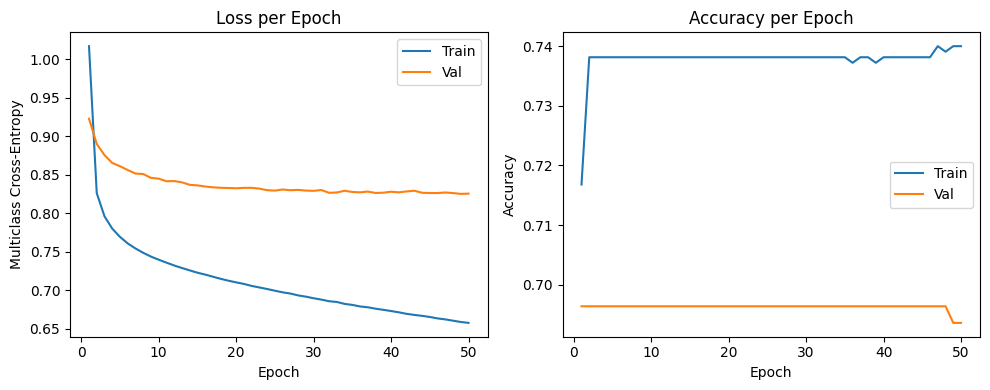

First five parameters: [-2.4094  0.3577  1.6854  0.3664 -0.0163]
Final loss  train: 0.6574
Final loss  val  : 0.8253
% difference (val-train): +25.55%


In [12]:
# YOUR CODE HERE

model_tf2 = build_model(X_train.shape[1], n_classes, learning_rate=0.1)

# 3. Fit the model

history = model_tf2.fit(X_train_f, Y_train, epochs=50, batch_size=32, validation_data=(X_val_f, Y_val), verbose=0)

# 4. Generate (1,2) plot

epochs = range(1, 51)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

##loss

axes[0].plot(epochs, history.history['loss'], label='Train')
axes[0].plot(epochs, history.history['val_loss'], label='Val')
axes[0].set_title('Loss per Epoch'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Multiclass Cross-Entropy'); axes[0].legend()

##accuracy

axes[1].plot(epochs, history.history['accuracy'], label='Train')
axes[1].plot(epochs, history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()


## results and hyperparameters
W, b = model_tf2.get_weights()
flat_params = np.concatenate([b, W.flatten()])

print("First five parameters:", np.round(flat_params[:5], 4))

train_final= history.history['loss'][-1]
val_final= history.history['val_loss'][-1]
pct_gap= 100 * (val_final - train_final) / train_final

print(f"Final loss  train: {train_final:.4f}")
print(f"Final loss  val  : {val_final:.4f}")
print(f"% difference (val-train): {pct_gap:+.2f}%")

---
### Step 6: Evaluation and generalization

### <span style="color:chocolate">Exercise 8:</span> Compute metrics (10 points)

Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

1. Calculate aggregate accuracy on both train and test datasets. Note: you will need to convert the vector of predicted probabilities to a class label using the argmax operation. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method provided by tf.keras. and the <span style="color:chocolate">np.max()</span> method available in NumPy.

2. Does the model demonstrate strong aggregate generalization capabilities? Provide an explanation based on your accuracy observations.

In [14]:
# YOUR CODE HERE

y_pred_train = model_tf.predict(X_train.astype('float32')).argmax(1)
y_pred_test  = model_tf.predict(X_test .astype('float32')).argmax(1)

acc_train = (y_pred_train == Y_train).mean()
acc_test  = (y_pred_test  == Y_test ).mean()

print(f"Accuracy  train: {acc_train:.3f} test: {acc_test:.3f}")

'''model fits the training data much better than the majority-class baseline and with the validation data still well below the baseline'''

12/12 [==============================] - 0s 1ms/step
Accuracy  train: 0.378 test: 0.365


'model fits the training data much better than the majority-class baseline and with the validation data still well below the baseline'

### <span style="color:chocolate">Exercise 9:</span> Additional metrics (10 points)

Using the test dataset:

1. Plot the confusion matrix. Identify which class the model confuses the most.

2. Determine which class has the lowest precision. What is the precision? Which class is the largest source of false positives?

3. Determine which class has the lowest recall. What is the recall? Which class is the largest source of false negatives?

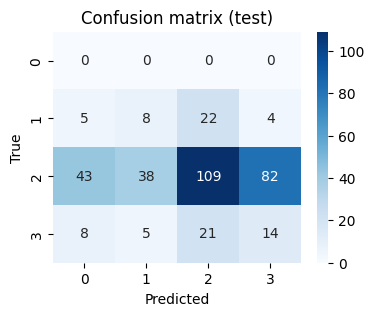

Most-confused (highest off-diag) true class → 2
Precision per class: [0.    0.157 0.717 0.14 ]
Lowest precision class 0  (0.000) largest source of false-positives
Recall per class: [0.    0.205 0.401 0.292]
Lowest recall class 0  (0.000) largest source of false-negatives


In [19]:
# YOUR CODE HERE

cm = confusion_matrix(Y_test, y_pred_test, labels=np.arange(n_classes))

## plotting
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(n_classes), yticklabels=np.arange(n_classes))
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion matrix (test)')
plt.show()

## determining lowest precision
off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)
most_confused = off_diag.sum(axis=1).argmax()
print("Most-confused (highest off-diag) true class →", most_confused)

## determining lowest recall
prec, rec, _, _ = precision_recall_fscore_support(Y_test, y_pred_test, labels=np.arange(n_classes), zero_division=0)

low_prec  = prec.argmin()
low_recall = rec.argmin()

print("Precision per class:", np.round(prec,3))
print("Lowest precision class", low_prec, f" ({prec[low_prec]:.3f}) largest source of false-positives")

print("Recall per class:", np.round(rec,3))
print("Lowest recall class", low_recall,f" ({rec[low_recall]:.3f}) largest source of false-negatives")

----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

Following the approach in Assignment 4 - Exercise 12, evaluate whether your model shows any signs of unfairness. Explain your findings and propose suggestions for improvement.

In [ ]:
# YOUR CODE HERE